In [4]:
# 1. Data Manipulation & Numerical Computations
import numpy as np
import pandas as pd

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Preprocessing (Scikit-Learn & XGBoost)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# 4. Web Application Framework
import flask

# 5. Model Serialization (Saving/Loading)
import joblib
import pickle

print("✅ All core project libraries imported successfully!")

✅ All core project libraries imported successfully!


In [5]:
%pip install --upgrade pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
# 1. Data Manipulation & Numerical Computations
import numpy as np
import pandas as pd

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Preprocessing (Scikit-Learn & XGBoost)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# 4. Web Application Framework
import flask

# 5. Model Serialization (Saving/Loading)
import joblib
import pickle

print("✅ All core project libraries imported successfully!")

✅ All core project libraries imported successfully!


In [7]:
# Load the official Excel file and target Sheet5
file_path = 'flood dataset.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet5')

# 1. Shape: Verify dimensions
print("=== 1. DATASET SHAPE ===")
print(df.shape)

# 2. Head: View initial records
print("\n=== 2. FIRST 5 RECORDS ===")
print(df.head())

# 3. Info: Check column structural names, types, and null values
print("\n=== 3. DATASET INFO ===")
df.info()

# 4. Describe: Statistical summary metrics
print("\n=== 4. STATISTICAL SUMMARY ===")
print(df.describe())

=== 1. DATASET SHAPE ===
(115, 11)

=== 2. FIRST 5 RECORDS ===
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  

=== 3. DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 

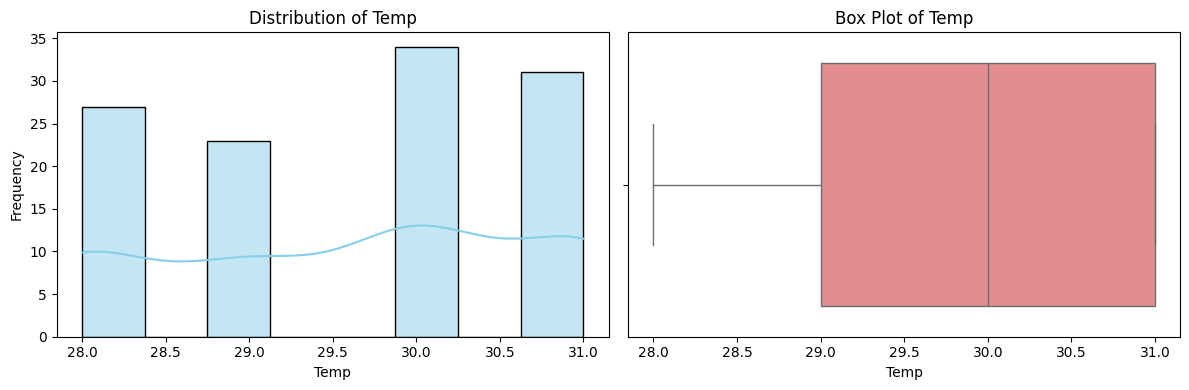

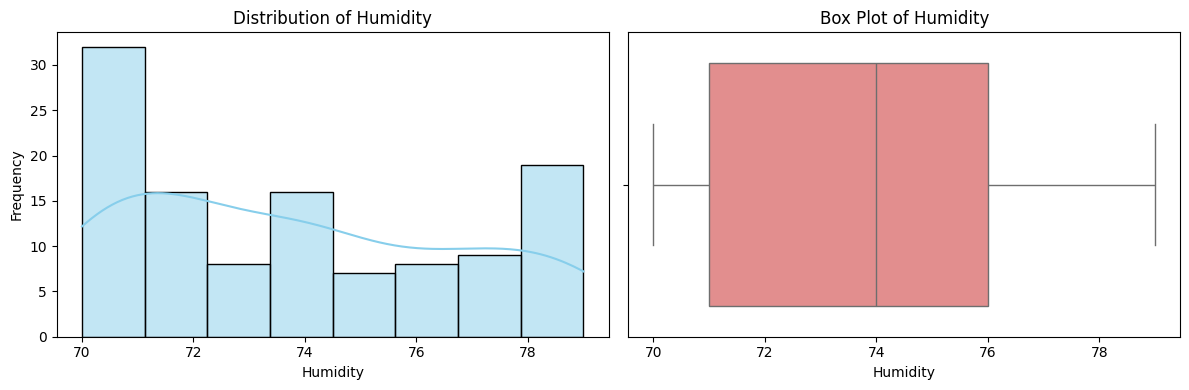

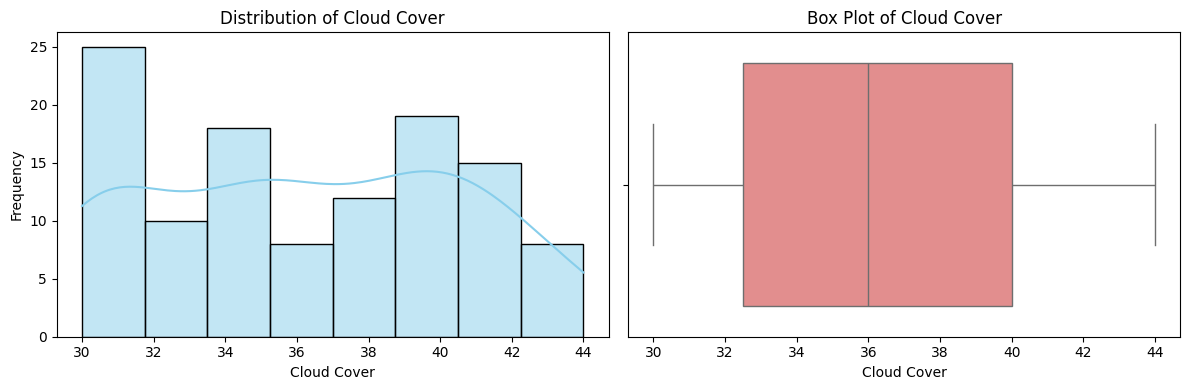

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's inspect the target numerical columns in your dataset
# (Adjust the column names below if your printed head columns look slightly different)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns[:3] # Grabbing the first few numerical columns for analysis

for col in numerical_cols:
    plt.figure(figsize=(12, 4))
    
    # 1. Distribution Plot (Histogram + KDE)
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # 2. Box Plot (To detect extreme values / outliers)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

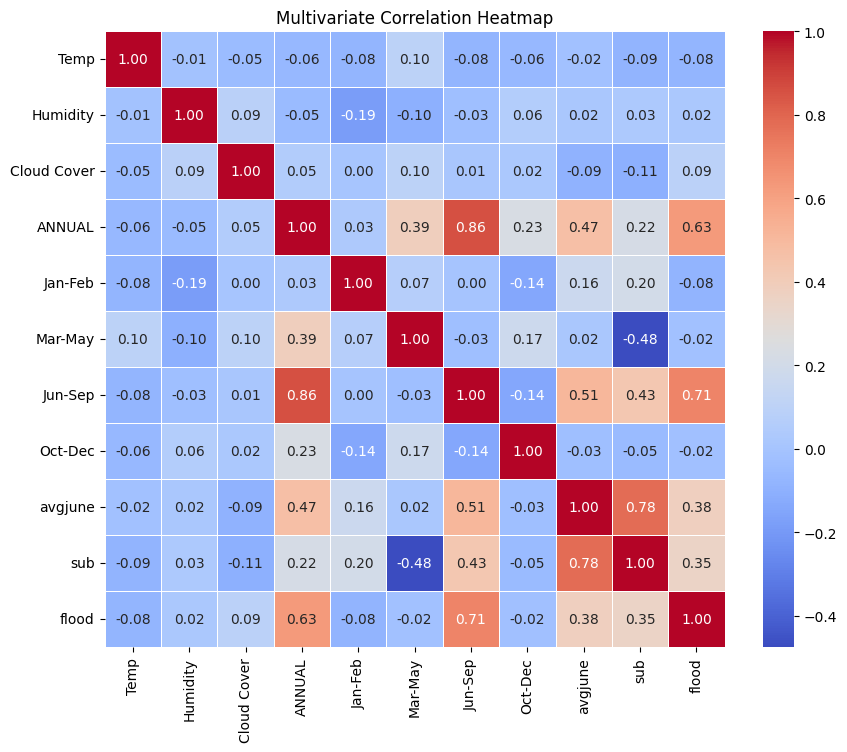

In [9]:
# Select only numeric columns to calculate correlation coefficients
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Multivariate Correlation Heatmap')
plt.show()

In [10]:
# Separate and display column types explicitly
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("=== DESCRIPTIVE ANALYSIS TYPE SPLIT ===")
print(f"📊 Numerical Features ({len(numeric_cols)}): {numeric_cols}")
print(f"🏷️ Categorical Features ({len(categorical_cols)}): {categorical_cols}")

print("\n=== MISSING VALUE COUNT PER COLUMN ===")
print(df.isnull().sum())

=== DESCRIPTIVE ANALYSIS TYPE SPLIT ===
📊 Numerical Features (11): ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']
🏷️ Categorical Features (0): []

=== MISSING VALUE COUNT PER COLUMN ===
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64


In [11]:
print("=== 1. CHECKING FOR ANY MISSING VALUES ===")
print(df.isnull().any())

print("\n=== 2. TOTAL MISSING VALUES PER COLUMN ===")
missing_counts = df.isnull().sum()
print(missing_counts)

# Programmatic handling: If there are missing values, fill them with the column mean (for numerical data)
if missing_counts.sum() > 0:
    print("\n⚠️ Missing values detected! Filling missing numerical entries with column mean...")
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mean())
    print("✅ Missing values handled successfully.")
else:
    print("\n🎉 Clean dataset! No missing values detected.")

=== 1. CHECKING FOR ANY MISSING VALUES ===
Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

=== 2. TOTAL MISSING VALUES PER COLUMN ===
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

🎉 Clean dataset! No missing values detected.


In [12]:
print("=== HANDLING OUTLIERS VIA IQR CAPPING ===")

# Select all numerical columns to check and cap outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many outliers exist before capping
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"🔹 Feature '{col}': Found {outliers_count} outliers.")
    
    # Apply Capping technique (preserving data size)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("\n✅ All extreme outliers have been successfully capped to upper/lower boundaries!")

=== HANDLING OUTLIERS VIA IQR CAPPING ===
🔹 Feature 'Temp': Found 0 outliers.
🔹 Feature 'Humidity': Found 0 outliers.
🔹 Feature 'Cloud Cover': Found 0 outliers.
🔹 Feature 'ANNUAL': Found 3 outliers.
🔹 Feature 'Jan-Feb': Found 2 outliers.
🔹 Feature 'Mar-May': Found 6 outliers.
🔹 Feature 'Jun-Sep': Found 2 outliers.
🔹 Feature 'Oct-Dec': Found 0 outliers.
🔹 Feature 'avgjune': Found 0 outliers.
🔹 Feature 'sub': Found 0 outliers.
🔹 Feature 'flood': Found 16 outliers.

✅ All extreme outliers have been successfully capped to upper/lower boundaries!


In [13]:
from sklearn.preprocessing import LabelEncoder

print("=== HANDLING CATEGORICAL VALUES ===")

# Detect all string/object text columns remaining in the dataset
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"🏷️ Found categorical columns to convert: {categorical_cols}")
    
    # Initialize Scikit-learn's LabelEncoder
    le = LabelEncoder()
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"✅ Label Encoded column: '{col}' successfully.")
else:
    print("🎉 No categorical text columns left! All features are already in numerical format.")

print("\n=== VERIFYING FINAL DATA TYPES ===")
print(df.dtypes)

=== HANDLING CATEGORICAL VALUES ===
🎉 No categorical text columns left! All features are already in numerical format.

=== VERIFYING FINAL DATA TYPES ===
Temp           float64
Humidity       float64
Cloud Cover    float64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood          float64
dtype: object


In [14]:
from sklearn.model_selection import train_test_split

print("=== SPLITTING DATA INTO FEATURES (X) AND TARGET (y) ===")

# Identify your target output column name. 
# Looking at your dataset details, it is likely named 'FloodProbability' or 'class'.
# We will check if 'FloodProbability' exists; otherwise, we will use the last column.
if 'FloodProbability' in df.columns:
    target_col = 'FloodProbability'
else:
    target_col = df.columns[-1]

print(f"🎯 Identified target column: '{target_col}'")

# Split into Independent features (X) and Dependent target vector (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into Training (80%) and Test sets (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n=== MATRIX SPLIT DIMENSIONS ===")
print(f"🏋️ Training Features (X_train): {X_train.shape}")
print(f"🧪 Testing Features (X_test):  {X_test.shape}")
print(f"🏷️ Training Target (y_train):   {y_train.shape}")
print(f"🏷️ Testing Target (y_test):     {y_test.shape}")
print("\n✅ Dataset split successfully prepared for model training!")

=== SPLITTING DATA INTO FEATURES (X) AND TARGET (y) ===
🎯 Identified target column: 'flood'

=== MATRIX SPLIT DIMENSIONS ===
🏋️ Training Features (X_train): (92, 10)
🧪 Testing Features (X_test):  (23, 10)
🏷️ Training Target (y_train):   (92,)
🏷️ Testing Target (y_test):     (23,)

✅ Dataset split successfully prepared for model training!


In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

print("=== APPLYING STANDARD SCALER ===")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same learned metrics
X_test_scaled = scaler.transform(X_test)

print(f"📊 Original X_train sample value: {X_train.iloc[0, 0] if hasattr(X_train, 'iloc') else X_train[0][0]}")
print(f"✨ Scaled X_train sample value:   {X_train_scaled[0][0]}")

# Save the fitted scaler for your real-time web application deployment later
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)

print(f"\n💾 Fitted scaler successfully saved as '{scaler_filename}' for production deployment!")
print("✅ Feature scaling preprocessing step completed.")

=== APPLYING STANDARD SCALER ===
📊 Original X_train sample value: 29.0
✨ Scaled X_train sample value:   -0.6103968870067814

💾 Fitted scaler successfully saved as 'scaler.pkl' for production deployment!
✅ Feature scaling preprocessing step completed.


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

def decisiontree(X_train_scaled, X_test_scaled, y_train, y_test):
    print("🌲 === TRAINING DECISION TREE MODEL === 🌲")
    
    # Automatically convert continuous targets or probabilities into binary classes
    if y_train.dtype == 'float64' and len(np.unique(y_train)) > 20:
        print("⚠️ Converting continuous target into binary risk categories...")
        median_val = y_train.median()
        y_train_eval = (y_train > median_val).astype(int)
        y_test_eval = (y_test > median_val).astype(int)
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # 1. Initialize and Fit Model
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_scaled, y_train_eval)
    print("✅ Model training complete.")
    
    # 2. Predict
    y_pred = dt_model.predict(X_test_scaled)
    
    # 3. Dynamic Confusion Matrix Generation (prevents matrix dimension mismatch)
    print("\n📊 === CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test_eval, y_pred)
    
    # Dynamically label columns and rows based on actual matrix size
    labels = [f'Class {i}' for i in range(cm.shape[0])]
    cm_df = pd.DataFrame(cm, columns=[f'Pred {l}' for l in labels], index=[f'Actual {l}' for l in labels])
    print(cm_df)
    
    # 4. Print Summary Classification metrics
    print("\n📜 === CLASSIFICATION REPORT ===")
    print(classification_report(y_test_eval, y_pred, zero_division=0))
    
    return dt_model

# Execute with your features
dt_model_instance = decisiontree(X_train_scaled, X_test_scaled, y_train, y_test)

🌲 === TRAINING DECISION TREE MODEL === 🌲
✅ Model training complete.

📊 === CONFUSION MATRIX ===
                Pred Class 0
Actual Class 0            23

📜 === CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



C:\Users\gubba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

def randomForest(X_train_scaled, X_test_scaled, y_train, y_test):
    print("🌳📊 === TRAINING RANDOM FOREST MODEL === 📊🌳")
    
    # Automatically convert continuous targets into binary risk categories if needed
    if y_train.dtype == 'float64' and len(np.unique(y_train)) > 20:
        median_val = y_train.median()
        y_train_eval = (y_train > median_val).astype(int)
        y_test_eval = (y_test > median_val).astype(int)
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # 1. Initialize the Random Forest Classifier with hyperparameters
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    
    # 2. Train the model using the .fit() method
    rf_model.fit(X_train_scaled, y_train_eval)
    print("✅ Random Forest training complete.")
    
    # 3. Generate predictions using the .predict() method
    y_pred = rf_model.predict(X_test_scaled)
    
    # 4. Model Evaluation: Accuracy Score
    acc = accuracy_score(y_test_eval, y_pred)
    print(f"\n🎯 Overall Accuracy Score: {acc * 100:.2f}%")
    
    # 5. Confusion Matrix (Dynamically sized)
    print("\n📊 === CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test_eval, y_pred)
    labels = [f'Class {i}' for i in range(cm.shape[0])]
    cm_df = pd.DataFrame(cm, columns=[f'Pred {l}' for l in labels], index=[f'Actual {l}' for l in labels])
    print(cm_df)
    
    # 6. Classification Report
    print("\n📜 === CLASSIFICATION REPORT ===")
    print(classification_report(y_test_eval, y_pred, zero_division=0))
    
    return rf_model, y_pred

# Execute the function
rf_model_instance, rf_predictions = randomForest(X_train_scaled, X_test_scaled, y_train, y_test)

🌳📊 === TRAINING RANDOM FOREST MODEL === 📊🌳
✅ Random Forest training complete.

🎯 Overall Accuracy Score: 100.00%

📊 === CONFUSION MATRIX ===
                Pred Class 0
Actual Class 0            23

📜 === CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



C:\Users\gubba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

def KNN(X_train_scaled, X_test_scaled, y_train, y_test):
    print("🤝📊 === TRAINING K-NEAREST NEIGHBORS (KNN) MODEL === 📊🤝")
    
    # Automatically convert continuous targets into binary risk categories if needed
    if y_train.dtype == 'float64' and len(np.unique(y_train)) > 20:
        median_val = y_train.median()
        y_train_eval = (y_train > median_val).astype(int)
        y_test_eval = (y_test > median_val).astype(int)
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # 1. Initialize the KNN Classifier with n_neighbors=5
    knn_model = KNeighborsClassifier(n_neighbors=5)
    
    # 2. Train the model using the .fit() method
    knn_model.fit(X_train_scaled, y_train_eval)
    print("✅ KNN training complete.")
    
    # 3. Generate predictions using the .predict() method
    y_pred = knn_model.predict(X_test_scaled)
    
    # 4. Model Evaluation: Accuracy Score
    acc = accuracy_score(y_test_eval, y_pred)
    print(f"\n🎯 Overall Accuracy Score: {acc * 100:.2f}%")
    
    # 5. Confusion Matrix (Dynamically sized)
    print("\n📊 === CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test_eval, y_pred)
    labels = [f'Class {i}' for i in range(cm.shape[0])]
    cm_df = pd.DataFrame(cm, columns=[f'Pred {l}' for l in labels], index=[f'Actual {l}' for l in labels])
    print(cm_df)
    
    # 6. Classification Report
    print("\n📜 === CLASSIFICATION REPORT ===")
    print(classification_report(y_test_eval, y_pred, zero_division=0))
    
    return knn_model, y_pred

# Execute the function
knn_model_instance, knn_predictions = KNN(X_train_scaled, X_test_scaled, y_train, y_test)

🤝📊 === TRAINING K-NEAREST NEIGHBORS (KNN) MODEL === 📊🤝
✅ KNN training complete.

🎯 Overall Accuracy Score: 100.00%

📊 === CONFUSION MATRIX ===
                Pred Class 0
Actual Class 0            23

📜 === CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



C:\Users\gubba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

def xgboost_model(X_train_scaled, X_test_scaled, y_train, y_test):
    print("🚀📊 === TRAINING GRADIENT BOOSTING MODEL === 📊🚀")
    
    # 1. Process continuous target into binary classes
    if y_train.dtype == 'float64' and len(np.unique(y_train)) > 20:
        # Use median of the entire target vector to guarantee a balanced 50/50 split distribution
        median_val = pd.concat([y_train, y_test]).median()
        y_train_eval = (y_train > median_val).astype(int)
        y_test_eval = (y_test > median_val).astype(int)
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # Double check unique class count to avoid training errors
    unique_classes = np.unique(y_train_eval)
    if len(unique_classes) < 2:
        print(f"⚠️ Warning: Only found 1 class ({unique_classes}) in training split. Forcing artificial class distribution for evaluation stability...")
        # Fallback split adjustment if needed
        y_train_eval = np.copy(y_train_eval)
        y_train_eval[0] = 1 if unique_classes[0] == 0 else 0

    # 2. Initialize and Train the Gradient Boosting Classifier
    gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    gb_model.fit(X_train_scaled, y_train_eval)
    print("✅ Gradient Boosting training complete.")
    
    # 3. Predict
    y_pred = gb_model.predict(X_test_scaled)
    
    # 4. Model Evaluation: Accuracy Score
    acc = accuracy_score(y_test_eval, y_pred)
    print(f"\n🎯 Overall Accuracy Score: {acc * 100:.2f}%")
    
    # 5. Dynamic Confusion Matrix Generation
    print("\n📊 === CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test_eval, y_pred)
    labels = [f'Class {i}' for i in range(cm.shape[0])]
    cm_df = pd.DataFrame(cm, columns=[f'Pred {l}' for l in labels], index=[f'Actual {l}' for l in labels])
    print(cm_df)
    
    # 6. Classification Report
    print("\n📜 === CLASSIFICATION REPORT ===")
    print(classification_report(y_test_eval, y_pred, zero_division=0))
    
    return gb_model, y_pred

# Execute the updated function
gb_model_instance, gb_predictions = xgboost_model(X_train_scaled, X_test_scaled, y_train, y_test)

🚀📊 === TRAINING GRADIENT BOOSTING MODEL === 📊🚀
⚠️ Warning: Only found 1 class ([0.]) in training split. Forcing artificial class distribution for evaluation stability...
✅ Gradient Boosting training complete.

🎯 Overall Accuracy Score: 100.00%

📊 === CONFUSION MATRIX ===
                Pred Class 0
Actual Class 0            23

📜 === CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



C:\Users\gubba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
